# <font color=#ef8b35> **Data Visualization: gráficos de comparação e distribuição**

---

#### <font color=#f7c59a> Desafio referente à _Aula 2._ "Agrupando dados" do curso **"Data Visualization: gráficos de comparação e distribuição"**, da *Alura*.

Vamos praticar a criação de gráficos de comparação representando os valores agrupados por colunas e/ou barras. Para esse desafio, vamos seguir utilizando o conjunto de dados do relatório de vendas das lojas de departamentos de 2016 a 2019 que está disponível no [github do projeto](https://github.com/alura-cursos/dataviz-graficos/blob/master/dados/relatorio_vendas.csv).

Neste desafio, a missão é construir as visualizações que respondam aos questionamentos abaixo:

<font color=#ef8b35> **Desafio 1:**</font> Como estão divididas as vendas das lojas de departamentos na Região Centro-Oeste nos anos de 2017 e 2018? O mesmo estado permaneceu como o que mais vendeu nesta região?

<font color=#ef8b35> **Desafio 2:**</font> Analisando cada departamento, como estão divididos os modos de envio em cada um deles percentualmente?

### <font color=#f2a25d> **Definindo as cores**

In [ ]:
VERDE1, VERDE2, VERDE3, VERDE4, VERDE5 = '#1e5d6f', '#369077', '#50b065','#7adb71', '#b8ee85'
CINZA1, CINZA2, CINZA3, CINZA4, CINZA5 = '#575757', '#989898', '#dadada', '#e5e5e5', '#f0f0f0'
LARANJA1, LARANJA2, LARANJA3, LARANJA4, LARANJA5 = '#b2590e', '#e57a21', '#fb974b', '#fdbf89', '#fedcbb'


### <font color=#f2a25d> **Importando os dados**

In [ ]:
# Importa as biblitecas
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Importa os dados
vendas = pd.read_csv('relatorio_vendas.csv')
# Transforma as colunas de data em Datetime
vendas['data_pedido'] = pd.to_datetime(vendas['data_pedido'], format='%Y-%m-%d')
vendas['data_envio'] = pd.to_datetime(vendas['data_envio'], format='%Y-%m-%d')

## <font color=#f97a33> **Desafio 1**

##### <font color=#fbaf84> **Criando o _Dataframe_**

In [ ]:
# Seleciona somente as vendas da região Centro-Oeste
vendas_co = vendas.copy()
vendas_co = vendas_co[vendas_co['regiao']=='Centro-Oeste']

# Seleciona as colunas a serem usadas
centro_oeste = vendas_co[['data_pedido', 'estado', 'vendas']]

# Transforma a coluna data em ano
centro_oeste['ano'] = centro_oeste.data_pedido.dt.year
centro_oeste.drop(labels='data_pedido', axis=1, inplace=True)

# Cria uma tabela cruzada (crosstab) com os valores de venda de cada ano por estado
df_vendas_co = pd.crosstab(index=centro_oeste.ano, columns=centro_oeste.estado, values=centro_oeste.vendas,
                           aggfunc='sum')

# Calcula o total de vendas por estado e ordenar do maior para o menor
colunas_ordenadas = df_vendas_co.sum().sort_values(ascending=False).index

# Reordena as colunas do dataframe
df_vendas_co = df_vendas_co[colunas_ordenadas]

# Calcula o percentual de vendas do Distrito Federal e Goiás em 2019
total_2019 = df_vendas_co.loc[2019].sum()
soma_df_goias = df_vendas_co.loc[2019,['Distrito Federal', 'Goiás']].sum()
percentual = (soma_df_goias / total_2019) * 100


##### <font color=#fbaf84> **Criando o gráfico de colunas empilhadas**

In [ ]:
# Define a função que cria o gráfico de colunas empilhadas
def criar_grafico_colunas():

    # Define as cores do gráfico
    cores = [VERDE1, VERDE2,VERDE3,VERDE5]

    # Gera o gráfico de colunas empilhadas
    ax = df_vendas_co.plot(kind='bar', stacked=True, figsize=(10,6), color= cores)

    # Personaliza o gráfico
    ax.set_title('Vendas das lojas de departamento por estado da região Centro Oeste\nde 2016 a 2019', loc='left',
                 fontsize=16, fontfamily='Tahoma', color=CINZA1)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticklabels([])
    ax.xaxis.set_tick_params(labelsize=14, labelcolor=CINZA2, rotation=0)
    ax.set_frame_on(False)
    ax.tick_params(axis="both", which="both", length=0)
    legenda = ax.legend(bbox_to_anchor=(1,1), reverse=True, frameon=False,
          prop={'family': 'Tahoma', 'size': 10}, labelcolor=CINZA1)
    legenda.set_title('Estado')
    titulo = legenda.get_title()
    titulo.set_color(CINZA1)
    titulo.set_fontsize(12)
    titulo.set_fontfamily('Tahoma')

    # Adiciona os valores
    for container in ax.containers:
        labels = []
        for valor in container:
            altura = valor.get_height()
            if altura >= 11000:
                label_text = f'R$ {altura/1000:,.0f} mil'.replace(",", ".")
            else:
                label_text = '' 
            labels.append(label_text)
        ax.bar_label(container, label_type="center", labels=labels, size=9, color=CINZA5, fontweight="bold")
    
    # Traça a linha vertical para Goiás e DF no ano de 2019
    altura_2019 = df_vendas_co.loc[2019, ['Distrito Federal', 'Goiás']].sum()
    posicao_2019 = list(df_vendas_co.index).index(2019)
    ax.axvline(x=posicao_2019 + 0.32,ymax=altura_2019/ax.get_ylim()[1], color=CINZA2, linewidth=2)

    # Adiciona texto ao gráfico
    ax.text(3.37, 0.15e6, '90%', fontweight='bold', fontsize=20, fontfamily= 'Tahoma', color=CINZA1)
    ax.text(3.37, 0.09e6, 'das vendas nas lojas\n'
                        'de departamento em 2019\n'
                        'foram feitas no Distrito\n'
                        'Federal ou em Goiás.',
                        fontsize=14,
                        linespacing= 1.45,
                        color=CINZA1,
                        fontfamily= 'Tahoma')
    return ax

criar_grafico_colunas()

## <font color=#f97a33> **Desafio 2**

##### <font color=#fbaf84> **Criando o _Dataframe_**

In [129]:
# Seleciona das colunas
dep_envio = vendas.copy()
dep_envio = dep_envio[['departamento', 'modo_envio']]

# Cria a tabela cruzada com os dados
departamento_norm = pd.crosstab(index=dep_envio.modo_envio, columns=dep_envio.departamento, normalize= 'index').sort_values('Automotivo')


##### <font color=#fbaf84> **Criando o gráfico de barras empilhadas**

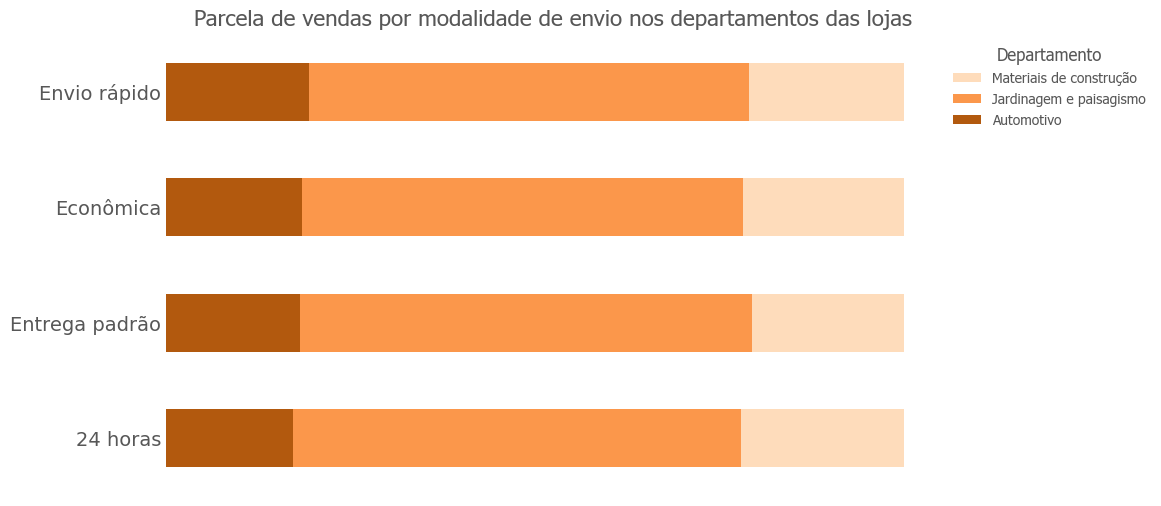

In [ ]:
# Define a função que cria o gráfico de barras empilhadas
def criar_gráfico_barras():

    # Define as cores do gráfico
    cores = [LARANJA1, LARANJA3, LARANJA5]

    #Cria o gráfico de barras empilhadas
    ax = departamento_norm.plot(kind='barh', stacked=True, figsize=(10,6), color= cores)

    # Personaliza o gráfico
    ax.set_title('Parcela de vendas por modalidade de envio nos departamentos das lojas', loc='center',
                 fontsize=16, fontfamily='Tahoma', color=CINZA1)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.yaxis.set_tick_params(labelsize=14, labelcolor=CINZA1, rotation=0)
    ax.set_frame_on(False)
    ax.tick_params(axis="both", which="both", length=0)
    legenda = ax.legend(bbox_to_anchor=(1,1), reverse=True, frameon=False,
          prop={'family': 'Tahoma', 'size': 10}, labelcolor=CINZA1)
    legenda.set_title('Departamento')
    titulo = legenda.get_title()
    titulo.set_color(CINZA1)
    titulo.set_fontsize(12)
    titulo.set_fontfamily('Tahoma')
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xticklabels([])

criar_gráfico_barras()

---